<img
    src="https://www.ingenieurs.com/images/article/1515_1.jpg" 
    alt=""
    height="200px" 
    width="200px"
    align=left
/> 
<br>
<br>

<center> <br>
  <h2 style="color:#7c7979";>MAA119 - Analyse numérique des équations aux dérivées partielles</h2>
</center>  

<center>
  <h2 style="color:#000000";>Séance 1 : Equations différentielles (1) : CORRECTION TP </h2>
</center>

# Questions du TP

On se propose d'étudier numériquement la solution de l'EDO $ \ \dfrac{{\rm d}u}{{\rm d}t} = f(u)$ dans les deux cas suivants :
* $f(u) = -a \ u$ : cas linéaire
* $f(u) = -a \ u^2$ : cas non linéaire (quadratique)

avec $a > 0 \in \mathbb{R}$ et on note $u_0 = u(0) \in \mathbb{R}$ la condition initiale.

Pour le cas **linéaire** $f(u(t)) = -a \ u(t)$, nous avons vu au début de ce cours que la **solution exacte** était : 

$$ u(t) = u_0 \ e^{-at} \ , \quad {\rm avec} \ t\ge 0$$

Pour le cas **non linéaire** $f(u(t)) = -a \ u(t)^2$, on peut montrer (en s'aidant de la partie "II - EDO à variables séparables du 1er ordre" du rappel de cours fourni dans Moodle) que la **solution exacte** est donnée par :

$$ u(t) = \dfrac{u_0}{1 + u_0 \ a \ t} \ , \quad {\rm avec} \ t\ge 0$$
(ce calcul analytique est laissé en exercice)

## Partie A : Euler explicite


**1)** Implémenter ci-dessous une fonction python `linear` qui à une valeur de $u$ donnée en entrée renvoie $-a \ u$ (remplacer les `?` par les instructions nécessaires).   
De même, implémenter une fonction python `quadra` qui à une valeur de $u$ donnée en entrée renvoie $-a \ u^2$.  

In [1]:
# Import des packages python
import time
import numpy as np
import scipy.optimize
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from math import log

In [2]:
# fonction python qui pour u donné renvoie f(u) = -a u
def linear(u) :
    a = 1.0
    f_u = - a * u
    return f_u

In [3]:
# fonction python qui pour u donné renvoie f(u) = -a u**2
def quadra(u) :
    a = 1.0
    f_u = - a * u ** 2
    return f_u

**2)** Le but de cette question est d'implémenter l'algorithme de la méthode d'Euler explicite.   
**a)** Dans un premier temps, lister l'ensemble des paramètres d'entrée nécessaires et des sorties de l'algorithme.   
**b)** Compléter ensuite la fonction python `EulerExplicite` ci-dessous.  

${\underline{Précision}}$ : L'ensemble des itérés $u^{n+1}$ de l'algorithme d'Euler explicite pourront être stockés dans un tableau `numpy` (voir les rappels à ce sujet dans le PDF "Bases de la programmation en Python" sur Moodle).

In [4]:
def EulerExplicite(func, u0, dt, T) :
    n = int(T / dt)
    u = np.zeros(n + 1)
    u[0] = u0
    for i in range(0, n) :
        u[i+1] = u[i] + dt * func(u[i]) 
    return u

**3)** Compléter la fonction python `tabtemps` ci-dessous dont le rôle est de renvoyer un tableau numpy contenant l'ensemble des valeurs de temps `t` de la discrétisation temporelle et ce à partir du temps final `T` de la simulation et du pas de temps `dt`.

In [5]:
def tabtemps(T, dt) :
    n = int(T / dt)
    t = np.zeros(n + 1)
    for i in range (0, n + 1):
        t[i] = i * dt 
    return t

**4)** Implémenter ci-dessous la fonction python `sol_ex_lin` qui pour un tableau numpy de valeurs temporelles `t` donné en entrée renvoie la solution exacte $u(t)$ du cas linéaire.   
De même, implémenter la fonction python `sol_ex_quad` qui pour un tableau numpy de valeurs temporelles `t` donné en entrée renvoie la solution exacte $u(t)$ du cas quadratique. 

In [6]:
def sol_ex_lin(t) :
    a = 1.0
    u0 = 1.0
    uex_t = np.exp(- a * t) * u0
    return uex_t 

In [7]:
def sol_ex_quad(t) :
    a = 1.0
    u0 = 1.0
    uex_t = u0 / (1 + u0 * a * t) 
    return uex_t 

**5)** Tester votre fonction `EulerExplicite` avec :
* **a)** le cas linéaire, avec $a=1$ et $u_0 = 1$
* **b)** le cas quadratique, avec $a=1$ et $u_0 = 1$

Dans chacun des deux cas ci-dessus faire varier les paramètres de la simulation (le temps final de la simulation $T$, pas de temps $\Delta t$, valeur de la ${\rm CFL}$ sur laquelle peut se baser le $\Delta t$, ...).   

Vous représenterez les résultats de vos différentes simulations graphiquement en appelant la fonction `graphique` donnée ci-dessous, déjà implémentée, permettant de tracer dans une même figure la courbe de la solution exacte et celle de la solution approchée.   

Vous ferez une synthèse finale sur l'ensemble des résultats obtenus.

${\underline{Attention}}$ : Il est important de ne faire varier qu'un seul paramètre à la fois pour étudier son influence.

In [8]:
def graphique(u, uex, T, dt) :
    '''
    Fonction tracant sur un même graphique la solution 
    exacte d'une EDO et sa solution approchée numériquement.
        @ u : solution numérique approchee
        @ uex : solution exacte
        @ T : temps final de la simulation
        @ dt : pas de temps de la discrétisation temporelle
    '''
    fig, ax = plt.subplots(figsize=(7,4))
    ax.set_xlim(-0.01, T + 0.1)

    t = tabtemps(T, dt) # fonction tabtemps implementée a la question 3
    ax.plot(t, uex, color='red', label='solution exacte ')
    ax.plot(t, u, color='black', marker='*', lw=0, label='solution approchee ')
    plt.xlabel('Temps')
    plt.ylabel('Solution u(t)')
    ax.grid(True)
    ax.legend(loc='best')

    plt.draw()

### Euler explicite : 
#### Résultats cas linéaire

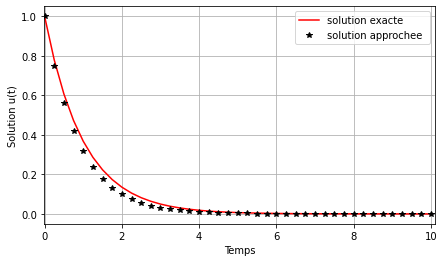

In [9]:
# Parametres simu
a = 1.0
u0 = 1.0
T = 10.
cfl = 0.125
dt = cfl * 2. / a

# Calcul de la solution approchée par appel de la fonction "EulerExplicite"
u_lin = EulerExplicite(linear, u0, dt, T)
# Calcul de la solution exacte par appel de "tabtemps" puis de "sol_ex_lin"
t = tabtemps(T, dt)
u_ex_lin = sol_ex_lin(t)

# Tracé des courbes par appel de "graphique"
graphique(u_lin, u_ex_lin, T, dt)

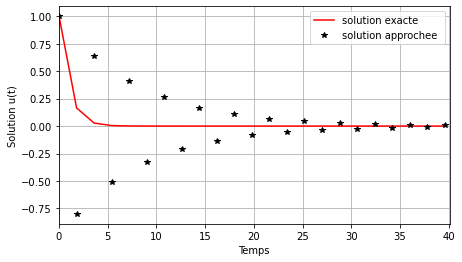

In [10]:
# Parametres simu
a = 1.0
u0 = 1.0
T = 40.
cfl = 0.9
dt = cfl * 2. / a

# Calcul de la solution approchée par appel de la fonction "EulerExplicite"
u_lin = EulerExplicite(linear, u0, dt, T)
# Calcul de la solution exacte par appel de "tabtemps" puis de "sol_ex_lin"
t = tabtemps(T, dt)
u_ex_lin = sol_ex_lin(t)

# Tracé des courbes par appel de "graphique"
graphique(u_lin, u_ex_lin, T, dt)

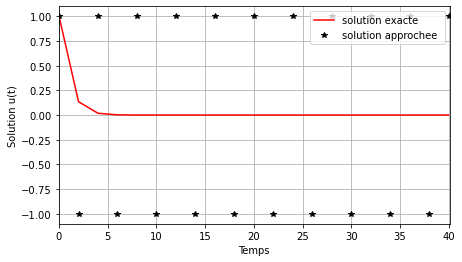

In [11]:
# Parametres simu
a = 1.0
u0 = 1.0
T = 40.
cfl = 1.0
dt = cfl * 2. / a

# Calcul de la solution approchée par appel de la fonction "EulerExplicite"
u_lin = EulerExplicite(linear, u0, dt, T)
# Calcul de la solution exacte par appel de "tabtemps" puis de "sol_ex_lin"
t = tabtemps(T, dt)
u_ex_lin = sol_ex_lin(t)

# Tracé des courbes par appel de "graphique"
graphique(u_lin, u_ex_lin, T, dt)

#### Résultats cas quadratique

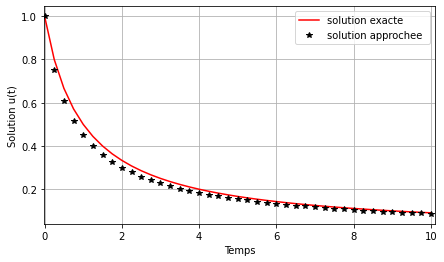

In [12]:
# Parametres simu
a = 1.0
u0 = 1.0
T = 10.
cfl = 0.125
dt = cfl * 2. / a

# Calcul de la solution approchée par appel de la fonction "EulerExplicite"
u_quad = EulerExplicite(quadra, u0, dt, T)
# Calcul de la solution exacte par appel de "tabtemps" puis de "sol_ex_quad"
t = tabtemps(T, dt)
u_ex_quad = sol_ex_quad(t)

# Tracé des courbes par appel de "graphique"
graphique(u_quad, u_ex_quad, T, dt)

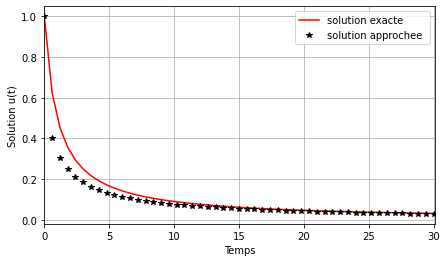

In [13]:
# Parametres simu
a = 1.0
u0 = 1.0
T = 30.
cfl = 0.3
dt = cfl * 2. / a

# Calcul de la solution approchée par appel de la fonction EulerExplicite
u_quad = EulerExplicite(quadra, u0, dt, T)
# Calcul de la solution exacte par appel de "tabtemps" puis de "sol_ex_quad"
t = tabtemps(T, dt)
u_ex_quad = sol_ex_quad(t)

# Tracé des courbes par appel de "graphique"
graphique(u_quad, u_ex_quad, T, dt)

## Partie B : Euler implicite

Le but de cette partie est maintenant d'implémenter la méthode d'Euler implicite.  
On a vu dans la partie cours que le calcul de l'itéré $u^{n+1}$ par la méthode d'Euler implicite reposait en fait sur la résolution de l'équation $(6)$ (potentiellement non linéaire si $f$ est non linéaire) :

$$(6) \quad \underbrace{\dfrac{u^{n+1}-u^n}{\Delta t} - f(u^{n+1})}_{g(u^{n+1})} = 0$$

**6)** Implémenter une fonction python `fonct_implicite` qui à partir d'une fonction mathématique $f$ donnée et des valeurs des itérés $u^{n+1}$ et $u^{n}$, renvoie la valeur $ \ g(u^{n+1}) = \dfrac{u^{n+1}-u^n}{\Delta t} - f(u^{n+1}) \ $ (membre de gauche de la relation $(6)$).

In [14]:
def fonct_implicite(u_np1, func, u_n):
    g_u = (u_np1 - u_n) / dt - func(u_np1)
    return g_u

**7)** Compléter la fonction python `EulerImplicite` ci-dessous. A chaque itération de votre algorithme, le calcul de l'itéré $u^{n+1}$ se fera en résolvant l'équation $(6)$. Pour cela on fera appel à une fonction existante de la librairie `scipy` (Scientific Python), à savoir la fonction `scipy.optimize.fsolve()`.

$\rightarrow$ Comment utiliser la fonction `scipy.optimize.fsolve()` ?
* arguments d'entrée : dans notre cas la fonction `fsolve` aura besoin de 3 arguments distints (à donner dans cet ordre) :
    * 1 fonction : la fonction python implémentant la fonction mathématique $g$ (ici, ce sera `fonct_implicite`)
    * 1 valeur : la valeur avec laquelle la fonction `fsolve` doit démarrer son algorithme : on pourra mettre $u^{n}$, l'itéré calculé à l'itération précédente
    * 1 [tuple](http://www.python-simple.com/python-langage/tuple.php) (=liste d'éléments écrits entre parenthèses et non entre crochets) : ce tuple contiendra les arguments dont la fonction $g$ va avoir besoin en interne : dans notre cas la fonction $g$ aura besoin de la fonction $f$ et de la valeur de l'itéré calculé à l'itération précédente $u^{n}$ => ces 2 arguments doivent être donnés dans cet ordre dans le tuple.
* sorties :
    * la fonction `fsolve` nous donnera 1 unique sortie : il s'agit de la solution $u^{n+1}$ 
    
Pour plus de détails sur la fonction `fsolve` voir la [documentation officielle](https://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.optimize.fsolve.html)

In [15]:
def EulerImplicite(func, u0, dt, T) :
    n = int(T / dt)
    u = np.zeros(n + 1)
    u[0] = u0
    for i in range(0,n) :
        u[i+1] = scipy.optimize.fsolve(fonct_implicite, u[i], (func, u[i]))
    return u

**7)** Reprendre la question **5)** de la partie A pour le cas de la méthode d'Euler implicite cette fois-ci.

### Euler implicite : 
#### Résultats cas linéaire

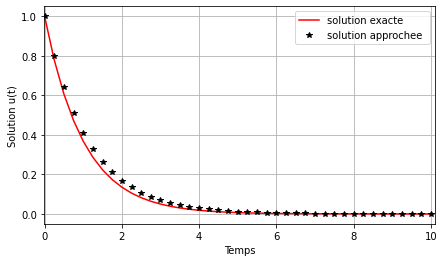

In [20]:
# Parametres simu
a = 1.0
u0 = 1.0
T = 10.
cfl = 0.125
dt = cfl * 2. / a

# Calcul de la solution approchée par appel de la fonction "EulerImplicite"
u_lin = EulerImplicite(linear, u0, dt, T)
# Calcul de la solution exacte par appel de "tabtemps" puis de "sol_ex_lin"
t = tabtemps(T, dt)
u_ex_lin = sol_ex_lin(t)

# Tracé des courbes par appel de "graphique"
graphique(u_lin, u_ex_lin, T, dt)

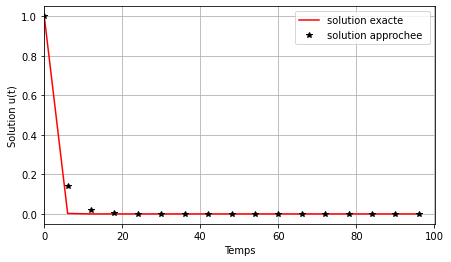

In [17]:
# Parametres simu
a = 1.0
u0 = 1.0
T = 100.
cfl = 3.
dt = cfl * 2. / a

# Calcul de la solution approchée par appel de la fonction "EulerImplicite"
u_lin = EulerImplicite(linear, u0, dt, T)
# Calcul de la solution exacte par appel de "tabtemps" puis de "sol_ex_lin"
t = tabtemps(T, dt)
u_ex_lin = sol_ex_lin(t)

# Tracé des courbes par appel de "graphique"
graphique(u_lin, u_ex_lin, T, dt)

#### Résultats cas quadratique

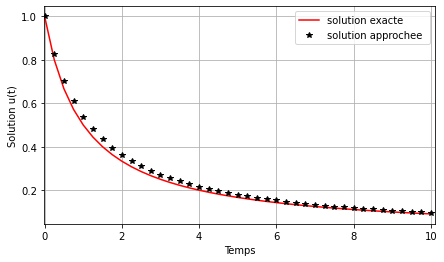

In [18]:
# Parametres simu
a = 1.0
u0 = 1.0
T = 10.
cfl = 0.125
dt = cfl * 2. / a

# Calcul de la solution approchée par appel de la fonction "EulerImplicite"
u_quad = EulerImplicite(quadra, u0, dt, T)
# Calcul de la solution exacte par appel de "tabtemps" puis de "sol_ex_quad"
t = tabtemps(T, dt)
u_ex_quad = sol_ex_quad(t)

# Tracé des courbes par appel de "graphique"
graphique(u_quad, u_ex_quad, T, dt)

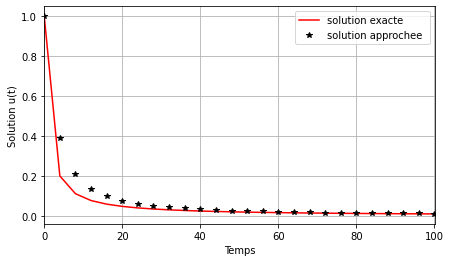

In [19]:
# Parametres simu
a = 1.0
u0 = 1.0
T = 100.
cfl = 2.0
dt = cfl * 2. / a

# Calcul de la solution approchée par appel de la fonction "EulerImplicite"
u_quad = EulerImplicite(quadra, u0, dt, T)
# Calcul de la solution exacte par appel de "tabtemps" puis de "sol_ex_quad"
t = tabtemps(T, dt)
u_ex_quad = sol_ex_quad(t)

# Tracé des courbes par appel de "graphique"
graphique(u_quad, u_ex_quad, T, dt)